## **MMAI: Homework 1**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.
2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.
3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?
4. What difficulties did you encounter in obtaining the data?
5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?


### Answer:
1. The goal of the model is to predict whether a patient is positive for a blood stream infection using multimodal patient data collected in the hospital. The model aims to integrate different types of data (e.g., vitals, notes, time series) to make accurate and timely predictions that could improve patient outcomes, support clinical decision-making, and potentially enable earlier interventions.

2. I have access to the multimodal Epic dataset which contains data from several hospitals through my research group. It contains patient vitals (structured/time series), clinical notes written by doctors and nurses (text), and tabular data including past diagnoses and chief complaints. These sources are highly relevant:
   - Vitals can capture physiological changes associated with infection.
   - Clinical notes often contain nuanced observations, suspicions, and descriptive factors not found in structured fields.
   - Tabular data is often the most reliable source of data and so we can extract definitive predictors for infection.
   Potential drawbacks include missing or inconsistently charted data, noisy clinical text, and uneven distribution of positivity in the data (less than 10% of patients are positive).

3. I plan to use tabular data, time series data (e.g., vital signs over time), and text (clinical notes). Image modalities (e.g., CT scans) are available but will not be used at this stage since radiology is less informative for predicting bloodstream infections compared to physiological and textual indicators. Including images adds technical complexity without clear additional benefit for this specific target task.

4. The main difficulty was not in accessing the data, but in preprocessing. This included defining positivity due to many false positives, dealing with high missingness cases, and selecting which variables to extract.

5. Addressing the six core challenges of multimodal learning (as defined in the paper):

   - **(1) Representation:** My approach is to develop effective representations that meaningfully summarize information within each modality (e.g., tabular, text, time series). For example, I will encode text using transformer-based models, process time series with LSTMs, and use statistical summaries for tabular features. It's crucial that these representations capture the relevant relationships within each modality as well as their unique characteristics.
   - **(2) Alignment:** Different modalities (e.g., vitals and clinical notes) are not collected at the exact same times or frequencies, making it challenging to align corresponding events or features. I plan to align modalities around clinically relevant events (like suspected infection time) and use temporal windows to aggregate and link modality elements that likely refer to the same real-world event, facilitating meaningful interactions across modalities.
   - **(3) Reasoning:** The task requires the model to make inferences by integrating information across multiple modalities. I will explore architectures that support such cross-modal reasoning, for instance using attention mechanisms that allow the model to learn dependencies and perform the necessary inference steps from the combined representations.
   - **(4) Generation:** While the main task is predictive, I may explore generating synthetic data for some modalities (e.g., generating synthetic time series or clinical notes to augment the dataset), making sure that these generated modalities reflect the realistic relationships between data sources seen during training.
   - **(5) Transference:** To leverage shared knowledge between modalities, I will investigate transfer learning techniques, such as pretraining representations on one modality and transferring those insights to assist learning from another, or using cross-modal regularization to improve learning when one modality is scarce or noisy.
   - **(6) Quantification:** I will evaluate how well the multimodal model is able to represent, align, and reason across the modalities, and quantify its performance and uncertainty. This will include calibrating output risk predictions, understanding model confidence, and possibly measuring the contribution of each modality to the final decision to gain insight into the multimodal learning process.


(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  

### Answer
The difficulties I encountered in extracting the modalities included extracting vitals and notes. Due to the data being from Hartford Hospital, which is quite large and hard to navigate, there were many things specific to their database that I had to learn to use. For now, I only extracted the latest vitals and clinical notes for each encounter to the hospital. Additionally, since some notes are quite long, I separated each note larger than 512 tokens into chunks and performed average pooling with their resulting embeddings.


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = 'max_split_size_mb:512'

from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import gc
import warnings
warnings.filterwarnings('ignore')

import sys
import time
import pandas as pd
import gc
import numpy as np
from abc import ABC, abstractmethod
import torch
import torch.nn.functional as F
from typing import List
from functools import reduce
from transformers import AutoTokenizer, AutoModel, logging
from tqdm import tqdm
import pyodbc

#from embeddings_model_language import *

def generate_embeddings(spec = "CombinedNotes", suffix = "most_recent_1", load = False):
    """
    Generates embeddings for text.
    """

    if load:
        # Load from huggingface and save
        tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
        model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

        tokenizer.save_pretrained("/datafs_a/haim5_helper/CBERT-pretrained")
        model.save_pretrained("/datafs_a/haim5_helper/CBERT-pretrained")

        notes = pd.read_csv(f'/datafs_a/carolgao/haim14_data/blood_infection/notes_matched_{suffix}.csv')

    # Memory stuff
    with torch.no_grad():
        torch.cuda.empty_cache()

    gc.collect()

    # Generate embeddings

    tokenizer = AutoTokenizer.from_pretrained("/datafs_a/carolgao/CBERT-pretrained")
    model = AutoModel.from_pretrained("/datafs_a/carolgao/CBERT-pretrained")
    model = model.to('cuda')

    def tokenize_and_reshape(text, max_length=512):
        # Tokenize texts without splitting into chunks first
        encoded = tokenizer(text, return_tensors="pt")

        # Determine padding necessary to make input_ids length a multiple of max_length
        current_length = encoded.input_ids.size(1)
        padding_needed = (max_length - current_length % max_length) % max_length

        # Apply padding using torch.nn.functional.pad
        pad_config = (0, padding_needed)
        padded_input_ids = F.pad(encoded.input_ids, pad_config, value=tokenizer.pad_token_id)
        padded_token_type_ids = F.pad(encoded.token_type_ids, pad_config, value=0)
        padded_attention_mask = F.pad(encoded.attention_mask, pad_config, value=0)

        # Reshape the tensors to have sequences of max_length and send to cuda
        chunks = {
            'input_ids': padded_input_ids.reshape(-1, max_length).to('cuda'),
            'token_type_ids': padded_token_type_ids.reshape(-1, max_length).to('cuda'),
            'attention_mask': padded_attention_mask.reshape(-1, max_length).to('cuda')
        }

        return chunks


    def get_embedding(text):
        model.eval()
        with torch.no_grad():
            tokens = tokenize_and_reshape(text)

            # Obtain embeddings from model
            output = model(**tokens).pooler_output

            note_embedding = output.mean(dim=0).detach().to('cpu').numpy()

        torch.cuda.empty_cache()

        return note_embedding

    def obtain_embeddings(spec):
        # Replace missing values with empty string, important for BioBert error handling
        notes['CombinedNotes'] = notes['CombinedNotes'].replace(to_replace=np.nan, value='')

        all_embeddings = np.array([get_embedding(x) for x in tqdm(notes[spec], desc="Embedding notes")])
        embeddings_df = pd.DataFrame(
            all_embeddings,
            columns=[f'cn_{i}' for i in range(all_embeddings.shape[1])]
        )

        processed = pd.concat(
                [notes[['PatientDurableKey', 'EncounterKey', 'OrderedDateKey', 'OrderedTimeOfDay']], embeddings_df],
                axis=1
            )
        processed.to_csv(f'/datafs_a/carolgao/haim14_data/blood_infection/blood_processed_notes_CombinedNotes_most_recent_1.csv', index=False)

        del embeddings_df

    obtain_embeddings(spec)

generate_embeddings()

In [ ]:
# Load blood culture data and merge with notes
final_cases = pd.read_csv("/datafs_a/carolgao/haim14_data/blood_infection/base_with_notes.csv")
notes_embeddings = pd.read_csv('/datafs_a/carolgao/haim14_data/blood_infection/blood_processed_notes_CombinedNotes_most_recent_1.csv')
df = final_cases.merge(notes_embeddings, how = "left", left_on=['PatientDurableKey','EncounterKey','OrderedDateKey','OrderedTimeOfDay'], right_on=['PatientDurableKey','EncounterKey','OrderedDateKey','OrderedTimeOfDay'])

# Select just one hospital: HH
def get_sql_connection():
    import pwd
    import json
    import os

    # get the current RHEL user running this script
    clientusr=pwd.getpwuid(os.getuid())[0]
    connection_string_json='/datafs_a/SQL/cstring'

    with open(connection_string_json) as f:
        data = json.load(f)
        srv = data['S']
        un  = data['U']
        pw  = data['P']
        db  = data['D']

    # Build unencoded connection string (for pyodbc directly)
    conn_str = (
        "DRIVER={ODBC Driver 18 for SQL Server};"
        f"SERVER={srv},1433;"
        f"DATABASE={db};"
        f"UID={un};"
        f"PWD={pw};"
        f"APP={clientusr};"
        "Encrypt=yes;"
        "TrustServerCertificate=yes;"
    )

    return pyodbc.connect(conn_str)

def send_query(sql_query):
    cursor.execute(sql_query)

    # Fetch column names
    columns = [column[0] for column in cursor.description]

    # Fetch all rows
    rows = cursor.fetchall()

    # Ensure rows are converted properly (each row is a tuple)
    df = pd.DataFrame.from_records([tuple(row) for row in rows], columns=columns)

    return df

#get a connection to mssql on HHCMITSQL001
conn = get_sql_connection()
cursor = conn.cursor()

def find_locations(encounters):
    locations = send_query(f"select distinct d1.EncounterKey, d2.LocationName from CAB_EPIC.dbo.PatientLocationEventFact d1 \
    INNER JOIN CAB_EPIC.dbo.DepartmentDim d2 on d1.DepartmentKey = d2.DepartmentKey \
    where d1.EncounterKey in ({encounters})" )
    locations = locations.loc[(locations['LocationName'] != "*Not Applicable") & (locations['LocationName'] != "*Unknown") & (locations['LocationName'] != "*Unspecified")]
    locations['Hospital'] = ""
    locations.loc[(locations['LocationName'].str.startswith("HHC BH")) | (locations['LocationName'].str.startswith("BH")), 'Hospital'] = "BH"
    locations.loc[(locations['LocationName'].str.startswith("HHC HH")) | (locations['LocationName'].str.startswith("HH ")), 'Hospital'] = "HH"
    locations.loc[(locations['LocationName'].str.startswith("HHC HOCC")) | (locations['LocationName'].str.startswith("HOCC")) | (locations['LocationName'] == 'HHC The Hospital of Central Connecticut Parent'), 'Hospital'] = "HOCC"
    locations.loc[(locations['LocationName'].str.startswith("HHC CH")) | (locations['LocationName'].str.startswith("CH")), 'Hospital'] = "CH"
    locations.loc[(locations['LocationName'].str.startswith("HHC SV")) | (locations['LocationName'].str.startswith("SV")), 'Hospital'] = "SV"
    locations.loc[(locations['LocationName'].str.startswith("HHC MMC")) | (locations['LocationName'].str.startswith("MMC")), 'Hospital'] = "MMC"
    locations.loc[(locations['LocationName'].str.startswith("HHC WH")) | (locations['LocationName'].str.startswith("WH")), 'Hospital'] = "WH"
    locations.loc[(locations['LocationName'].str.startswith("SBO")), 'Hospital'] = "SBO"
    locations = locations[['EncounterKey', 'Hospital']].drop_duplicates()
    return locations

encounters =",".join([str(x) for x in df['EncounterKey'].unique()])
locations = find_locations(encounters)
df = pd.merge(df, locations, how = 'left', on = ['EncounterKey'])
base_HH = df.loc[df['Hospital'] == "HH"]

# some cleaning up
base_HH = base_HH.rename(columns = {'Positive':'outcome'})
base_HH = base_HH.drop(columns = ['Unnamed: 0.1','Unnamed: 0','primarymrn','OrderedYear','BothPositive','Sets','FalsePositive', 'OrderedTimeOfDay'])

# write to data directory
base_HH.to_csv('data/base_HH.csv',index=False)

In [68]:
df = pd.read_csv("data/base_HH.csv")

# 2. Modalities in the loaded DataFrame:
#    - Tabular: "TabularText" (ICD diagnoses, chief complaints from structured fields)
#    - Text:    "Notes" (clinical notes, from which we obtain embeddings)
tab_cols = [c for c in df.columns \
                if (c.startswith("icd_") or c.startswith("cmp_") or c.startswith("rx_") \
                    or c in ["Temp", "SpO2", "Pulse", "Resp", "HighFever", "LowFever", "HighPulse", "LowOxygen"])]
emb_cols = [c for c in df.columns if c.startswith("cn_")]
tabular = df[tab_cols]
notes = df[emb_cols]

print("Extracted tabular modalities shape:", tabular.shape)
print("Extracted text modalities shape:", notes.shape)
print("Modalities: TabularText (tabular), Notes (text)")
print("Positive rate: {:.2%}".format(df["outcome"].mean()))
print(df.head(3))

Extracted tabular modalities shape: (41064, 3435)
Extracted text modalities shape: (41064, 768)
Modalities: TabularText (tabular), Notes (text)
Positive rate: 8.74%
   PatientDurableKey  EncounterKey  OrderedDateKey  outcome  SpO2  Resp  \
0          131848795     512973361        20250702        0  98.0  22.0   
1          131848757     512973293        20250703        0  94.0  23.0   
2          131820606     512336657        20250630        0  96.0  18.0   

   Pulse   Temp  HighFever  LowFever  ...    cn_759    cn_760    cn_761  \
0   79.0  102.6          1         0  ... -0.054131  0.127419 -0.071395   
1   72.0  100.2          0         0  ... -0.190735  0.151044 -0.218993   
2   86.0  101.0          1         0  ... -0.062733  0.145661 -0.026658   

     cn_762    cn_763    cn_764    cn_765    cn_766    cn_767  Hospital  
0 -0.111109 -0.061929  0.054889  0.998868 -0.169442  0.999979        HH  
1 -0.278780 -0.039126  0.018900  0.853542 -0.004919  0.999550        HH  
2 -0.053565

(15 pts)

As part of this assignment, we will look into visualizing your dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualizations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

## Answer:
I visualized the dataset using t-SNE and UMAP to assess how well each modality separates positive and negative cases, and to understand the structure of the multimodal data. First, I used t-SNE it is well-suited for visualizing complex, non-linear data structures and finding clusters. UMAP is similar to t-SNE but it is particularly good for high-demnsional data.

I applied t-SNE and UMAP separately to the tabular features and the notes embedding features. I tuned perplexity (5, 15, 30, 50) and n_iter (300, 500, 1000) for t-SNE and tuned n_neighbors (5, 15, 30, 50) and min_dist (0.0, 0.1, 0.3, 0.5) for UMAP.

Across both methods and modalities, the visualizations show that there is no clear separation: Positive and negative cases overlap substantially in the 2D embeddings. Despite using different combinations of hyperparameters, we see that this result holds across modalities and settings. This suggests that the dataset is highly complex (and possibly noisy). The prediction task likely requires non-linear, multimodal integration rather than simple feature-based separations.

In [69]:
# Packages (feel free to include more if needed)!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

# Data Distribution

In [70]:
def visualize_data_distribution(data, x_feature="t-SNE 1", y_feature="t-SNE 2", num_components=2,
                                perplexity=30, num_iterations=2000, labels=None, title="Data distribution"):
    """Visualizes the distribution of data in 2D using t-SNE. Scatter plot instead of distplot."""
    tsne = TSNE(n_components=num_components, perplexity=min(perplexity, len(data) - 1), max_iter=num_iterations, random_state=42)
    tsne_data = tsne.fit_transform(data)
    plt.figure(figsize=(10, 6))
    if labels is not None and len(np.unique(labels)) == 2:
        for lab in [0, 1]:
            mask = labels == lab
            plt.scatter(tsne_data[mask, 0], tsne_data[mask, 1], alpha=0.6, label=f"Outcome={lab}", s=20)
        plt.legend()
    else:
        plt.scatter(tsne_data[:, 0], tsne_data[:, 1], alpha=0.6, s=20)
    plt.title(title)
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.tight_layout()
    plt.show()

# Samples

In [83]:
def visualize_samples(data, num_samples = 100):
  """
  Visualizes samples from the dataset.

  Args:
      data (np.array): The dataset that you plan on using as a 2D representation.
      num_samples (int): The number of samples to visualize.
  """

  if num_samples > len(data):
    print(f"Error: Number of samples ({num_samples}) exceeds the dataset size ({len(data)}).")

  # Create np array out of randomly selected samples.
  # Change replace based on if you want to sample with or without replacement
  rng = np.random.default_rng(42)
  idx = rng.choice(len(data), size=num_samples, replace=False)
  random_samples = data[idx]

  visualize_data_distribution(random_samples)

# Input Distribution

In [84]:
def visualize_input_distribution(data):
  """
  Visualizes input_distribution from the dataset.

  Args:
      data (np.array): The dataset that you plan on using as a 2D representation.
  """
  visualize_data_distribution(data)



Data distribution (t-SNE of numeric features)


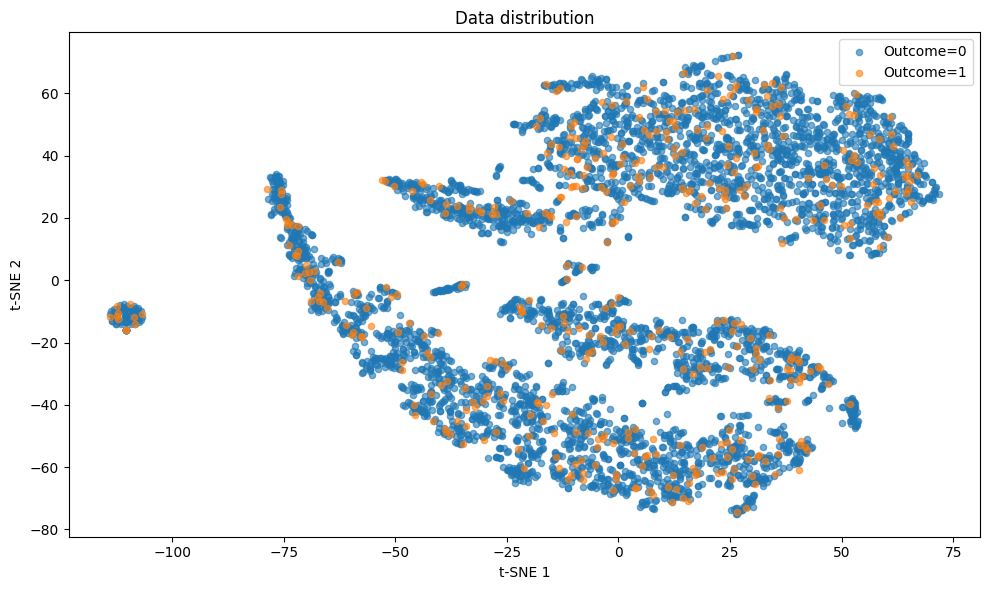

Sample distribution (t-SNE of numeric features)


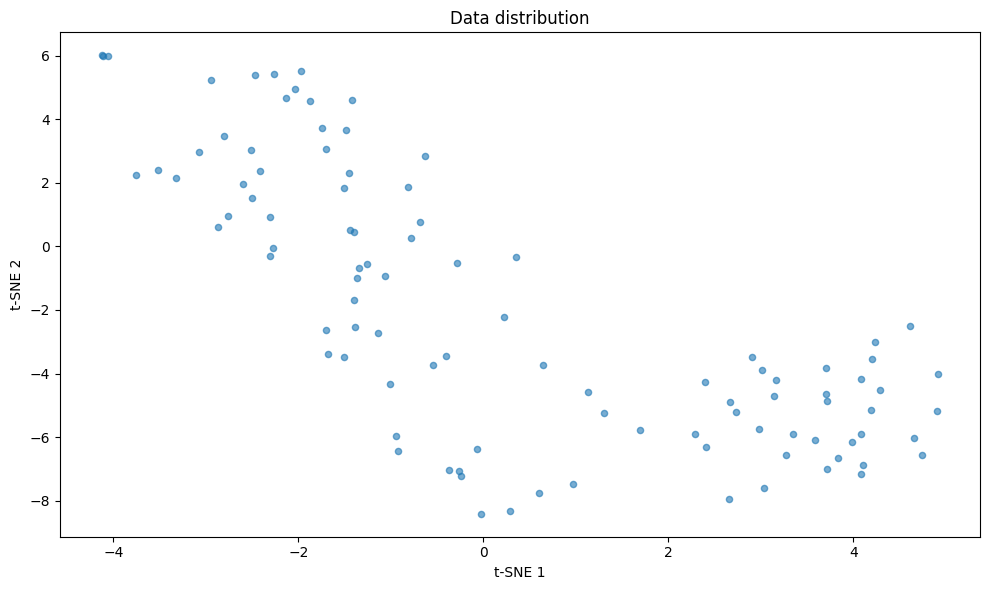

In [85]:
################## VISUALIZE TABULAR DATA ##################

# Prepare numeric data for t-SNE (from df) and run all three visualizations.
# Uses the provided functions with modifications: 2D scatter for t-SNE output, row sampling, outcome coloring.

np.random.seed(42)

# Build numeric feature matrix for t-SNE: use tabular columns (icd_*, cmp_*, etc.) if present
X = df[tab_cols].values
labels = df["outcome"].values

print("Data distribution (t-SNE of numeric features)")
visualize_data_distribution(X_viz, labels=labels_viz, perplexity=30)

print("Sample distribution (t-SNE of numeric features)")
visualize_samples(X_viz)

Data distribution (t-SNE of notes embeddings)


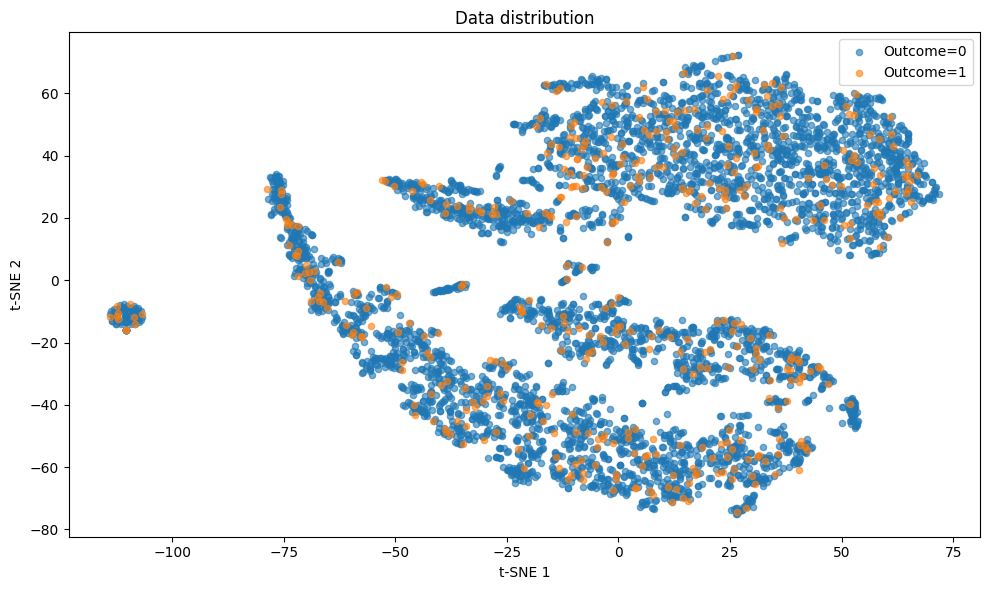

Sample distribution (t-SNE of embeddings)


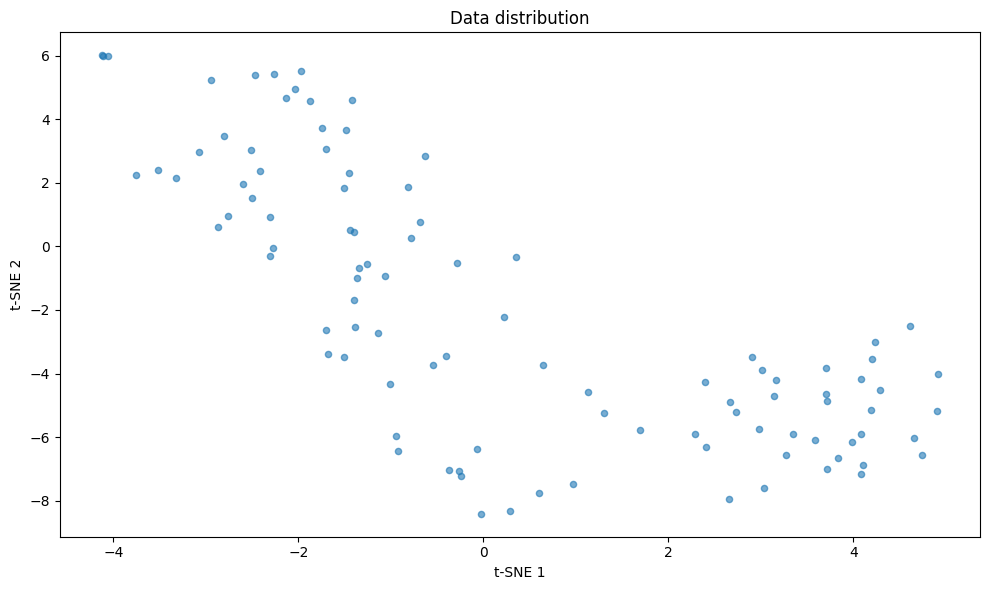

In [86]:
################## VISUALIZE EMBEDDINGS ##################
X = df[emb_cols].values
labels = df["outcome"].values

print("Data distribution (t-SNE of notes embeddings)")
visualize_data_distribution(X_viz, labels=labels_viz, perplexity=30, num_iterations=2000)

print("Sample distribution (t-SNE of embeddings)")
visualize_samples(X_viz)

Input distribution


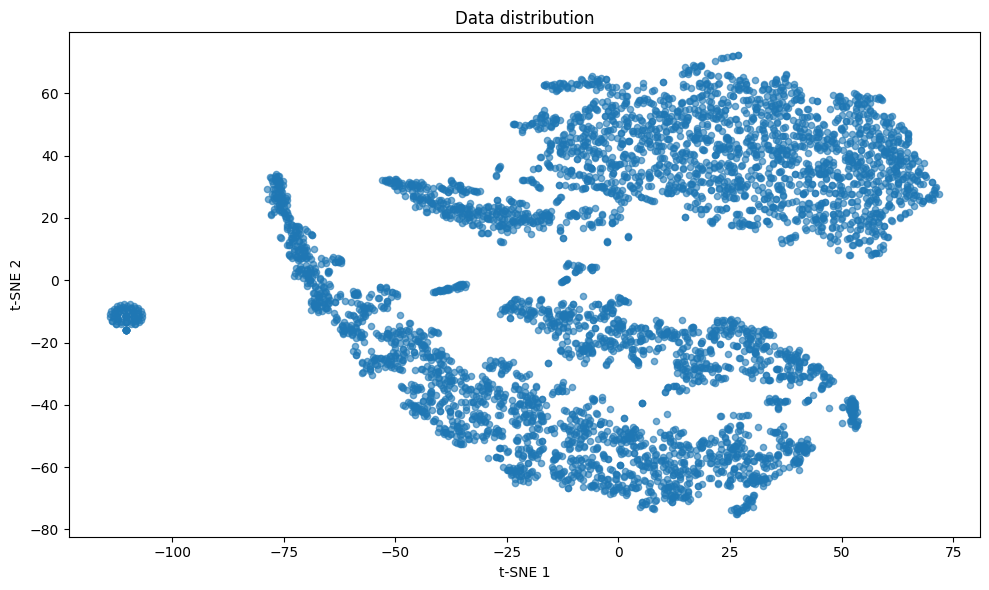

In [88]:
################## VISUALIZE FEATURES ##################
features = tab_cols + emb_cols
X = df[emb_cols].values
labels = df[features].values

print("Input distribution")
visualize_input_distribution(X_viz)

UMAP VISUALIZATIONS BY MODALITY

1. TABULAR DATA (ICD codes, Chief Complaints)
   Shape: (41064, 3435)


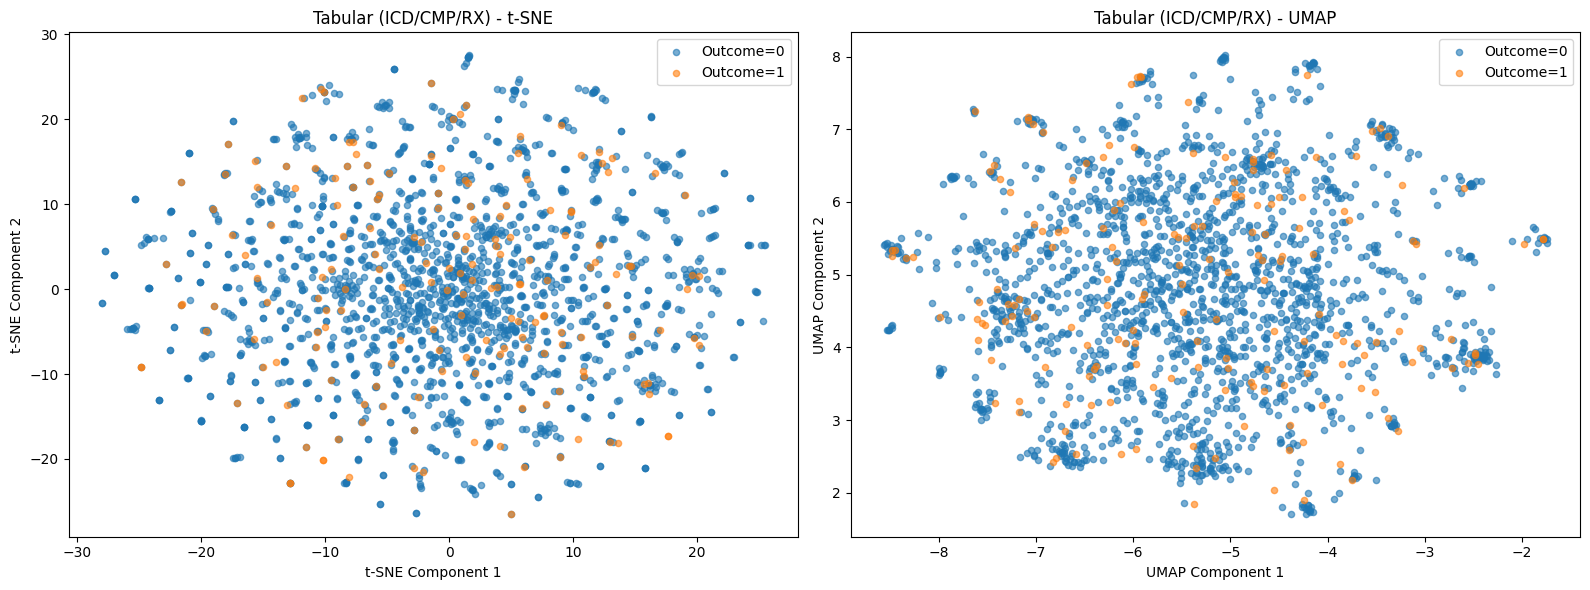


2. TEXT DATA (Clinical Notes)
   Shape: (41064, 3435)


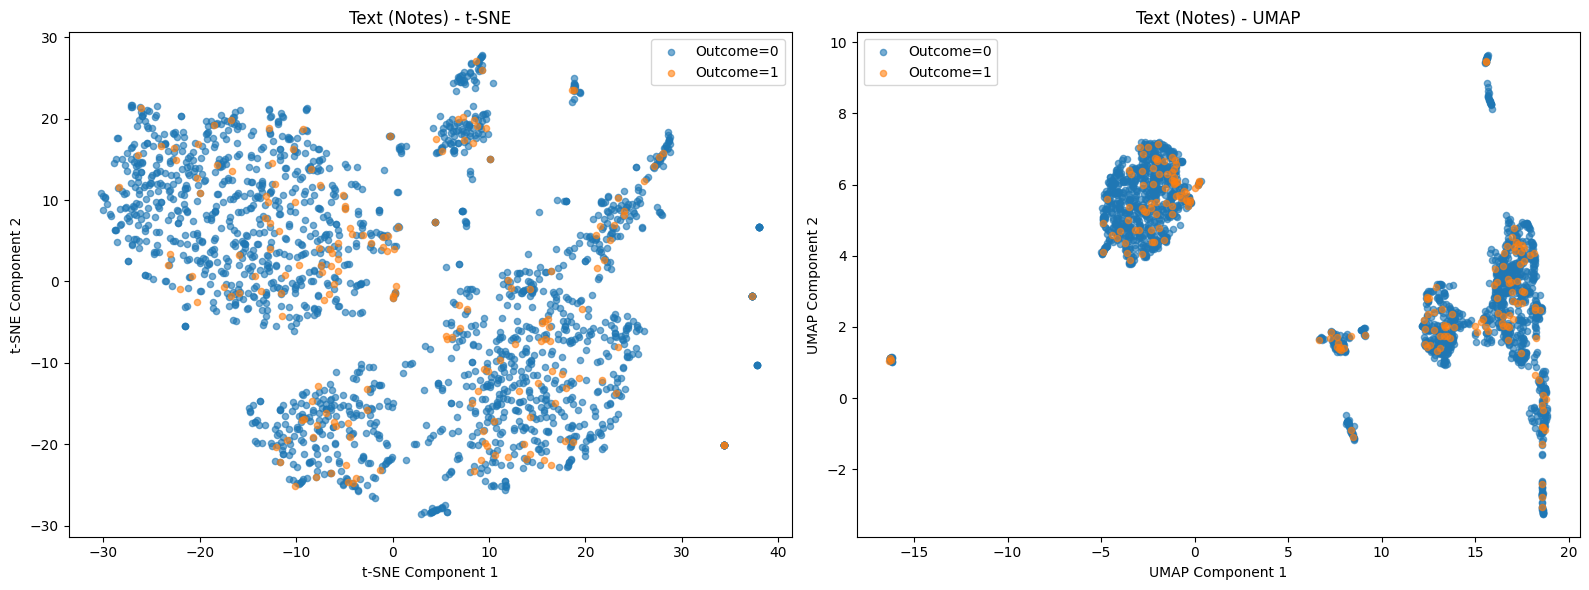

In [89]:
# Comparison between t-SNE and UMAP
import umap
def compare_tsne_vs_umap(feature_matrix, labels, modality_name,
                         perplexity=30, n_neighbors=15, min_dist=0.1, max_points=2000):
    """
    Side-by-side comparison of t-SNE and UMAP for the same data.
    """
    # Subsample if needed
    if len(feature_matrix) > max_points:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(feature_matrix), size=max_points, replace=False)
        X_viz = feature_matrix[idx]
        labels_viz = labels[idx] if labels is not None else None
    else:
        X_viz = feature_matrix
        labels_viz = labels

    # Standardize
    scaler = StandardScaler()
    X_viz_scaled = scaler.fit_transform(X_viz)

    # Run t-SNE
    tsne = TSNE(n_components=2,
                perplexity=min(perplexity, len(X_viz) - 1),
                max_iter=500,
                random_state=42)
    tsne_data = tsne.fit_transform(X_viz_scaled)

    # Run UMAP
    reducer = umap.UMAP(n_neighbors=min(n_neighbors, len(X_viz) - 1),
                       min_dist=min_dist,
                       n_components=2,
                       random_state=42)
    umap_data = reducer.fit_transform(X_viz_scaled)

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # t-SNE plot
    ax1 = axes[0]
    if labels_viz is not None and len(np.unique(labels_viz)) == 2:
        for lab in [0, 1]:
            mask = labels_viz == lab
            ax1.scatter(tsne_data[mask, 0], tsne_data[mask, 1],
                       alpha=0.6, label=f"Outcome={lab}", s=20)
        ax1.legend()
    else:
        ax1.scatter(tsne_data[:, 0], tsne_data[:, 1], alpha=0.6, s=20)
    ax1.set_title(f'{modality_name} - t-SNE')
    ax1.set_xlabel('t-SNE Component 1')
    ax1.set_ylabel('t-SNE Component 2')

    # UMAP plot
    ax2 = axes[1]
    if labels_viz is not None and len(np.unique(labels_viz)) == 2:
        for lab in [0, 1]:
            mask = labels_viz == lab
            ax2.scatter(umap_data[mask, 0], umap_data[mask, 1],
                       alpha=0.6, label=f"Outcome={lab}", s=20)
        ax2.legend()
    else:
        ax2.scatter(umap_data[:, 0], umap_data[:, 1], alpha=0.6, s=20)
    ax2.set_title(f'{modality_name} - UMAP')
    ax2.set_xlabel('UMAP Component 1')
    ax2.set_ylabel('UMAP Component 2')

    plt.tight_layout()
    plt.show()

# ===== Visualize each modality with UMAP =====
print("=" * 60)
print("UMAP VISUALIZATIONS BY MODALITY")
print("=" * 60)

# Prepare labels
labels = df["outcome"].values if "outcome" in df.columns else None

# MODALITY 1: TABULAR DATA
print("\n1. TABULAR DATA (ICD codes, Chief Complaints)")
X_tabular = df[tab_cols].values.astype(np.float64)
print(f"   Shape: {X_tabular.shape}")
compare_tsne_vs_umap(X_tabular, labels, "Tabular (ICD/CMP/RX)", perplexity=30, n_neighbors=15, min_dist=0.1)

# MODALITY 2: TEXT DATA
print("\n2. TEXT DATA (Clinical Notes)")
X_notes = df[emb_cols].values.astype(np.float64)
print(f"   Shape: {X_tabular.shape}")
compare_tsne_vs_umap(X_notes, labels, "Text (Notes)", perplexity=30, n_neighbors=15, min_dist=0.1)

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

### Answer:
1. I plan to use AUC as the main metric because it is scale-invariant and is useful for comparing model performances with imbalanced datasets.
2. Other metrics that can be useful are calibration and recall (false negative rate). Recall is important here because it is vital that we do not miss any patients positive for infection. In this medical setting, a high number of false positives is far less worrisome than a high number of false negatives.
3. Here are the pros and cons for the metrics that I will use:
- **AUC (Area Under the ROC Curve)**:
    - Pros: AUC provides a single number summarizing model performance across all possible classification thresholds, not just a single point. This makes it far superior to accuracy. It is robust to class imbalance, making it especially useful for my dataset where there are less than 10% positives.
    - Cons: It does not directly inform about performance at any specific cutoff or threshold.
- **Recall (Sensitivity)**:
    - Pros: High recall ensures that most or all true positive cases (e.g., infected patients) are identified, which is critical for patient safety.
    - Cons: Focusing solely on recall can lead to many false positives (lower specificity), meaning more patients are unnecessarily flagged. This also ignores other important metrics such as accuracy.
- **Calibration:**:
    - Pros: Indicates how well-predicted probabilities correspond to actual event rates, which is valuable for risk estimates.
    - Cons: Does not directly reflect classification performance.

In [ ]:
from sklearn.metrics import recall_score, roc_auc_score, brier_score_loss

def calculate_recall(predictions, ground_truths):
    return recall_score(ground_truths, predictions)

def calculate_auc(probabilities, ground_truths):
    return roc_auc_score(ground_truths, probabilities)

def calculate_calibration(probabilities, ground_truths):
    return brier_score_loss(ground_truths, probabilities)

(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. This is when you prompt the model in specifc ways to guarentee a specific output. Provide prompts that would be able to guarentee the right output based on the data.

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

### Answer:
**Scenario 1**:
You are a sentiment classification system.

Task: Classify the sentiment of the restaurant review below.

Allowed labels (choose one):
- positive
- negative
- neutral

Rules:
- Output only one label from the list.
- Do not explain.
- Do not output anything else.

Review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"

Label:


**Scenario 2**: You are an emotion classifier.

Task: Identify the facial emotion in the image.

Allowed labels (choose one):
- angry
- sad
- happy

Rules:
- Output only one label from the list.
- Do not explain.
- Do not output anything else.

Emotion:

**Scenario 3**: You are an information extraction system.

Task: extract the following fields from the paragraph:
- subject_name
- destination_country
- planned_activity

Rules:
- Output must be a valid JSON
- Use exactly these keys: subject_name, destination_country, planned_activity
- Do not add extra keys
- If information is missing, use null

Paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Output JSON:
Given the paragraph, extract the following: the name of the subject,

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training and testing using the evaluation metrics

Be sure to provide a rationale for each design choice!

## ANSWER:
* Task: Predicting humor 🤣🤣
* Dataset: Kaggle's 200K SHORT TEXTS FOR HUMOR DETECTION dataset
* Modalities: tabular and text
* Model: logistic regression - always best to start simple!
* Evaluation metrics: accuracy for overall correctness, AUC for threshold-independent ranking, and F1 for balance of precision/recall, particularly when dealing with imbalanced classes, though that is not the case here.
* Results: I was able to achieve an accuracy of 96.9%, AUC of 0.995, and F1 score of 0.969. Clearly, a simple model was sufficient to obtain great results.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Load the dataset
df_humor = pd.read_csv("data/humor_dataset.csv")
print("1. LOAD DATA")
print(f"   Rows: {len(df_humor):,}, Columns: {list(df_humor.columns)}")
print(f"   Humor distribution: {df_humor['humor'].value_counts().to_dict()}")

# Preprocess: clean text and encode labels
df_humor = df_humor.dropna(subset=["text", "humor"])
df_humor["text"] = df_humor["text"].astype(str).str.strip()
# Handle both boolean and string "True"/"False" from CSV
humor_vals = df_humor["humor"].astype(str).str.lower()
df_humor["label"] = (humor_vals == "true").astype(int)
y = df_humor["label"].values
X_raw = df_humor["text"].values
print("\n2. PREPROCESS")
print(f"   After dropna: {len(df_humor):,} samples. Label distribution: {pd.Series(y).value_counts().to_dict()}")

# Train/validation/test split
X_rest, X_test, y_rest, y_test = train_test_split(
    X_raw, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_rest, y_rest, test_size=0.15 / (1 - 0.15), random_state=42, stratify=y_rest
)
print("\n3. SPLIT")
print(f"   Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")

# Extract modality: text → BERT encodings
# Rationale: BERT gives contextualized embeddings that capture meaning better than bag-of-words.
# We use DistilBERT (smaller/faster than BERT) and mean-pool last hidden state for one vector per text.
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()

def get_bert_encodings(texts, batch_size=BATCH_SIZE):
    """Encode texts with BERT; returns (n_samples, hidden_size) numpy array."""
    all_embeds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="BERT encoding"):
        batch = texts[i : i + batch_size]
        enc = tokenizer(
            list(batch),
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = bert_model(**enc).last_hidden_state  # (batch, seq, dim)
            # Mean-pool over non-padding tokens
            mask = enc["attention_mask"].unsqueeze(-1).float()
            pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        all_embeds.append(pooled.cpu().numpy())
    return np.vstack(all_embeds)

X_train_bert = get_bert_encodings(X_train)
X_val_bert = get_bert_encodings(X_val)
X_test_bert = get_bert_encodings(X_test)
print("\n4. MODALITY (TEXT → BERT encodings)")
print(f"   Feature matrix shape: {X_train_bert.shape} (DistilBERT, mean-pooled)")

# Run logistic regression
# Rationale: Linear classifier on top of frozen BERT encodings; fast to train and interpretable.
# class_weight='balanced' helps if humor class is imbalanced.
model = LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)
model.fit(X_train_bert, y_train)
print("\n5. MODEL: Logistic Regression on BERT encodings (balanced classes)")

# Obtain evaluation metrics
# Rationale: Accuracy for overall correctness; AUC for threshold-independent ranking;
# F1 for balance of precision/recall (useful if classes are imbalanced).
def evaluate(X, y, name):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    acc = accuracy_score(y, pred)
    auc = roc_auc_score(y, proba)
    f1 = f1_score(y, pred)
    print(f"   {name}: Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
    return pred, proba

print("\n6. EVALUATION METRICS (Accuracy, AUC, F1)")
evaluate(X_train_bert, y_train, "Train")
evaluate(X_val_bert, y_val, "Val")
pred_test, proba_test = evaluate(X_test_bert, y_test, "Test")


### OUTPUT 
Since the output of the previous cell was accidentally deleted between Google colab sessions:
4. MODALITY (TEXT → BERT encodings)
   Feature matrix shape: (139999, 768) (DistilBERT, mean-pooled)

5. MODEL: Logistic Regression on BERT encodings (balanced classes)

6. EVALUATION METRICS (Accuracy, AUC, F1)
   Train: Accuracy = 0.9700, AUC = 0.9954, F1 = 0.9700
   Val: Accuracy = 0.9673, AUC = 0.9947, F1 = 0.9674
   Test: Accuracy = 0.9686, AUC = 0.9950, F1 = 0.9686

(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!

### Answer:
1. The most interesting topic discussed in this homework assignment was exploring different ways of representing text data, especially the transition from simple bag-of-words (TF-IDF) approaches to using pretrained BERT embeddings. In the extra credit, I first tried use TF-IDF as my embedding method, and it performed significantly worse as compared to BERT embeddings. It was insightful to see how much the text modality and feature extraction method can impact model performance in a classification task.

2. A challenging aspect I did not expect was dealing with the high dimensionality in the feature space. Using data visualization and dimensionality tools such as t-SNE and UMAP helped to address this. I was able to obtain a better idea of the distribution of the data.

3. The overall quality of the dataset is decent due to its size, which is a strong advantage for machine learning tasks where large datasets help models generalize better. However, the features can be quite noise and the overall feature and outcome interactions are quite complex, making the dataset quality generally fine, but difficult for downstream tasks. Still, the diversity and richness of the text data provide lots of potential for feature exploration and robust model training.